# Handwritten Character Recognition - MNIST & EMNIST with a CNN

This notebook walks through the complete project: dataset choice, the EMNIST
orientation trap, EDA, preprocessing, augmentation, baselines, the CNN experiment
ladder, evaluation, error analysis and inference on new images.

It **loads results produced by the scripts in `src/`** rather than retraining, so
every number shown here is the same number quoted in `report.md`. To regenerate
them, see the commands in `README.md`.

## 0. Setup

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as ShowImage, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT / 'src'))

from utils import FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, describe_environment, load_json

def show(name, width=980):
    path = FIGURES_DIR / name
    if path.exists():
        display(ShowImage(filename=str(path), width=width))
    else:
        print('missing:', path)

describe_environment()

{'python': '3.12.10',
 'platform': 'Windows-11-10.0.26200-SP0',
 'processor': 'Intel64 Family 6 Model 140 Stepping 1, GenuineIntel',
 'cpu_count': 8,
 'numpy': '2.0.2',
 'seed': 42,
 'tensorflow': '2.18.1',
 'gpus': [],
 'scikit_learn': '1.5.2'}

## 1. Dataset strategy

| Variant | Classes | Train | Why / why not |
|---|---|---|---|
| MNIST | 10 | 60,000 | Digits only. Too easy for the main task - kept as a reference point. |
| EMNIST Digits | 10 | 240,000 | A larger MNIST; adds no character diversity. |
| EMNIST Letters | 26 | 124,800 | Letters only, no digits, case fully merged. |
| EMNIST ByClass | 62 | 697,932 | Most complete, but severely imbalanced and ~6x the compute. |
| EMNIST ByMerge | 47 | 697,932 | Same 47 classes as Balanced, but imbalanced and much larger. |
| **EMNIST Balanced** | **47** | **112,800** | **Chosen.** |

**Why EMNIST Balanced is the right choice:**

1. **It is genuinely a character task** - digits *and* letters, 47 classes.
2. **Exactly balanced** (2,400 train / 400 test per class), so accuracy and macro-F1
   measure real skill rather than a class prior. Any weakness in the results is a
   property of the *characters*, not of the sampling.
3. **Case handled honestly.** 15 letters (C I J K L M O P S U V W X Y Z) have upper-
   and lowercase forms that are indistinguishable in isolation, so EMNIST merges
   them. Penalising a model for calling an isolated `o` an `O` would be measuring
   an impossible task.
4. **Computationally reasonable** - trainable on a CPU in ~1.5-3.5 min/epoch, unlike
   the 698k-image ByClass/ByMerge variants.

## 2. Dataset inspection

Every statistic below is computed from the loaded arrays by `src/explore.py`.

In [2]:
summary = load_json(METRICS_DIR / 'dataset_summary.json')
e, m = summary['emnist_summary'], summary['mnist_summary']

for label, s in [('EMNIST Balanced', e), ('MNIST', m)]:
    print(label)
    print(f"  train / test : {s['n_train']:,} / {s['n_test']:,}")
    print(f"  image shape  : {s['image_shape']}  dtype {s['dtype']}")
    print(f"  classes      : {s['n_classes']}")
    print(f"  pixel range  : [{s['pixel_min']}, {s['pixel_max']}]  "
          f"mean {s['pixel_mean']:.2f}  std {s['pixel_std']:.2f}")
    print(f"  per-class train counts: {s['train_count_min']}-{s['train_count_max']} "
          f"(imbalance ratio {s['imbalance_ratio']:.2f})")
    print()

print('EMNIST classes:', ' '.join(e['class_names']))

EMNIST Balanced
  train / test : 112,800 / 18,800
  image shape  : [28, 28]  dtype uint8
  classes      : 47
  pixel range  : [0, 255]  mean 44.65  std 84.98
  per-class train counts: 2400-2400 (imbalance ratio 1.00)

MNIST
  train / test : 60,000 / 10,000
  image shape  : [28, 28]  dtype uint8
  classes      : 10
  pixel range  : [0, 255]  mean 33.32  std 78.57
  per-class train counts: 5421-6742 (imbalance ratio 1.24)

EMNIST classes: 0 1 2 3 4 5 6 7 8 9 A B C D E F G H I J K L M N O P Q R S T U V W X Y Z a b d e f g h n q r t


## 3. The EMNIST orientation trap (mandatory check)

EMNIST's IDX files store each image with the row and column axes **swapped**
relative to MNIST. Read naively, every character comes out mirrored and rotated 90
degrees - and a CNN will happily train to ~85% on the wrong orientation, which is
exactly why this mistake is easy to miss.

Rather than eyeballing it, the check is quantitative: EMNIST classes 0-9 are the
same digits as MNIST, so for each candidate transform we correlate the mean image
of every digit class against MNIST's. The correct transform wins by a wide margin.

In [3]:
orientation = summary['orientation']
for name, score in sorted(orientation['scores'].items(), key=lambda kv: -kv[1]):
    print(f'  {name:12s} {score:+.4f}')
print()
print('best transform   :', orientation['best'])
print('transpose correct:', orientation['correct'])

  transpose    +0.7977
  rot90_cw     +0.6350
  rot90_ccw    +0.6223
  as_stored    +0.4591
  flip_ud      +0.4120
  flip_lr      +0.4049

best transform   : transpose
transpose correct: True


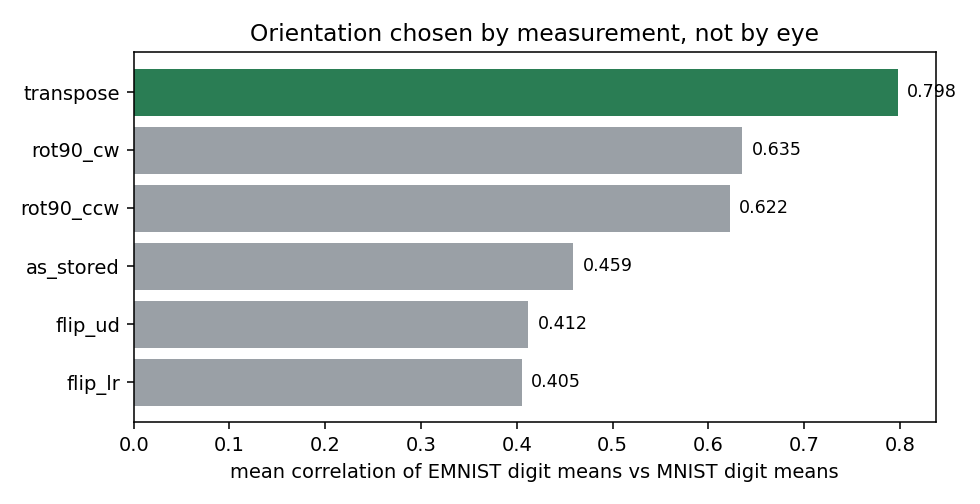

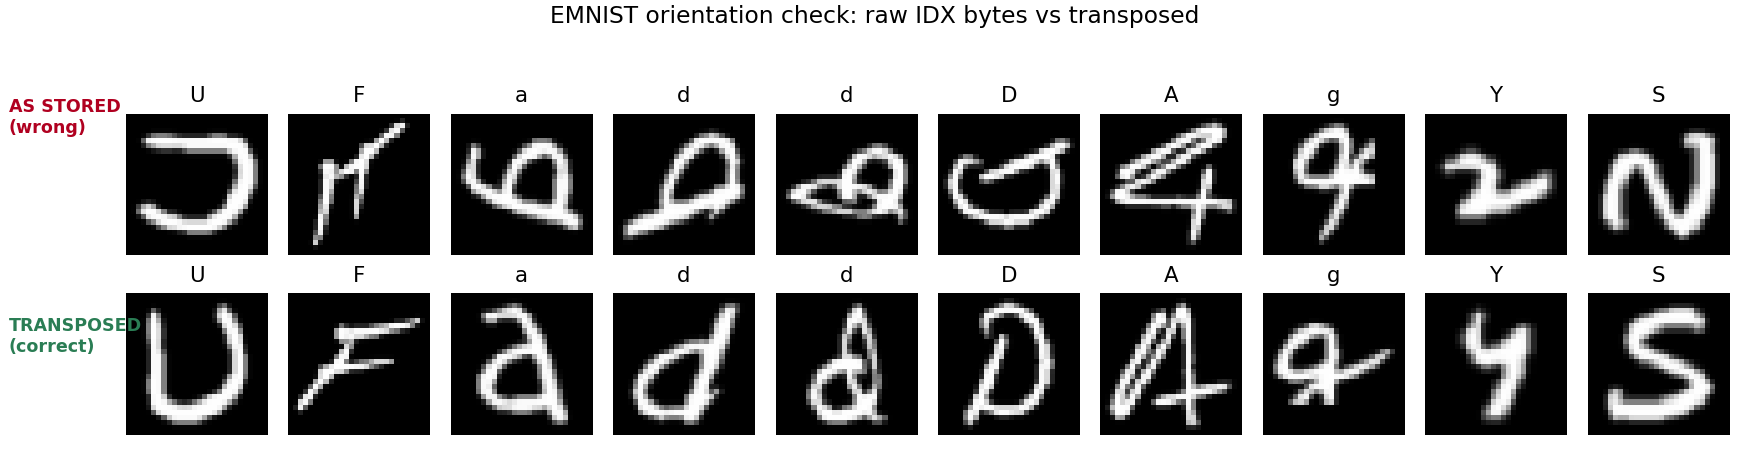

In [4]:
show('phase3_orientation_scores.png', 720)
show('phase3_orientation_check.png')

The top row is what the raw bytes give you; the bottom row is after the
transpose. The metric and the picture agree.

## 4. Exploratory data analysis

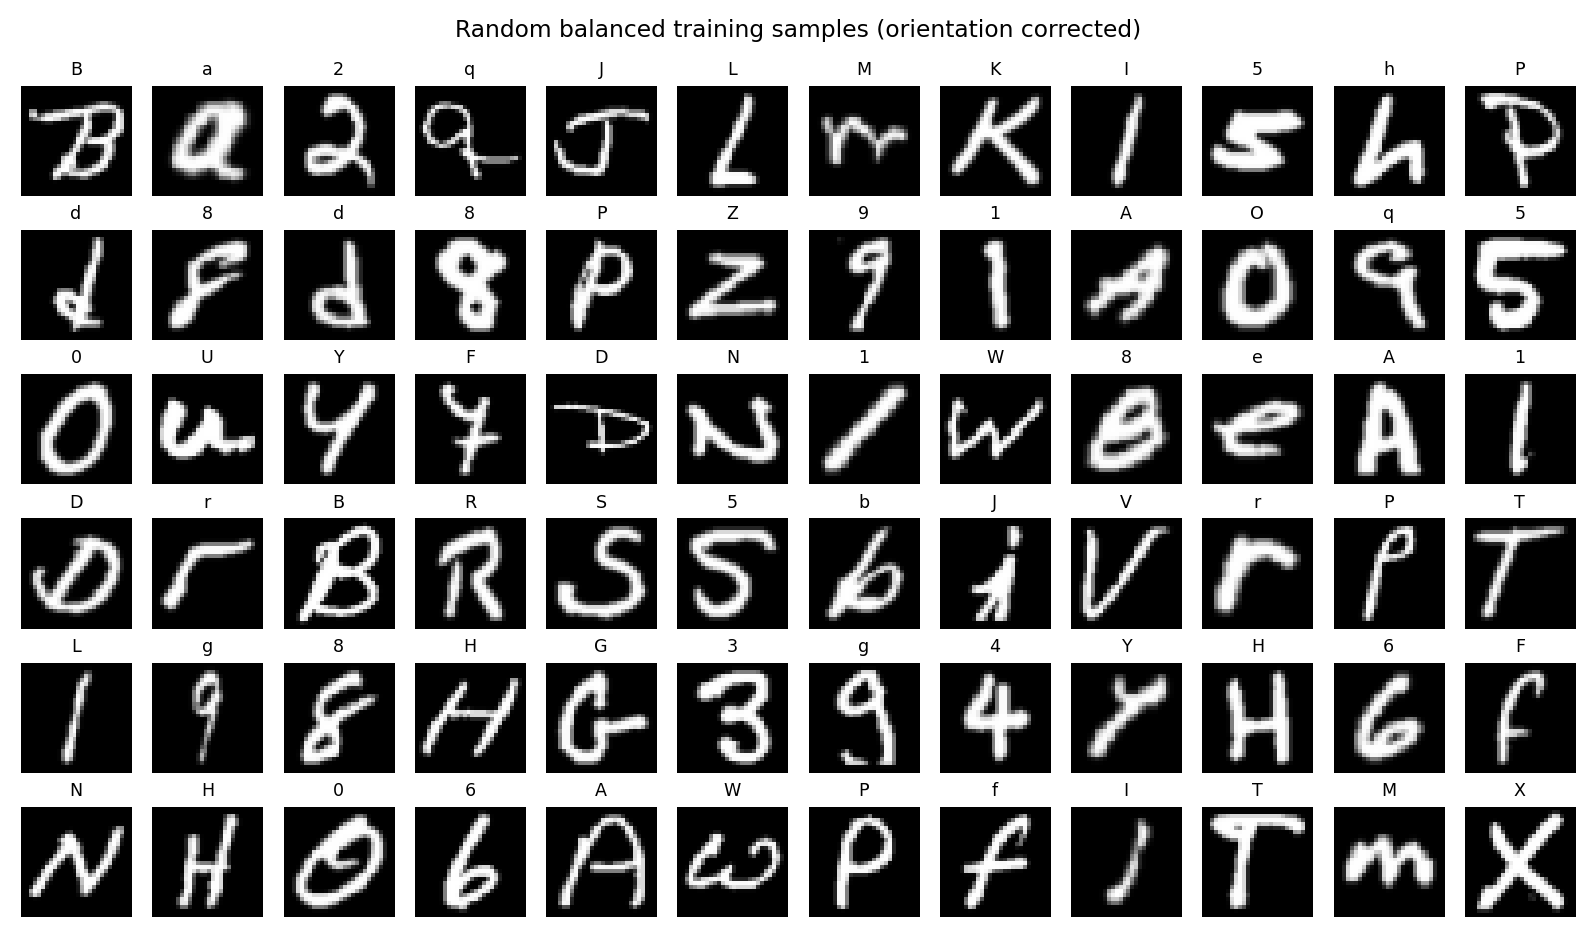

In [5]:
show('eda_balanced_sample_grid.png')

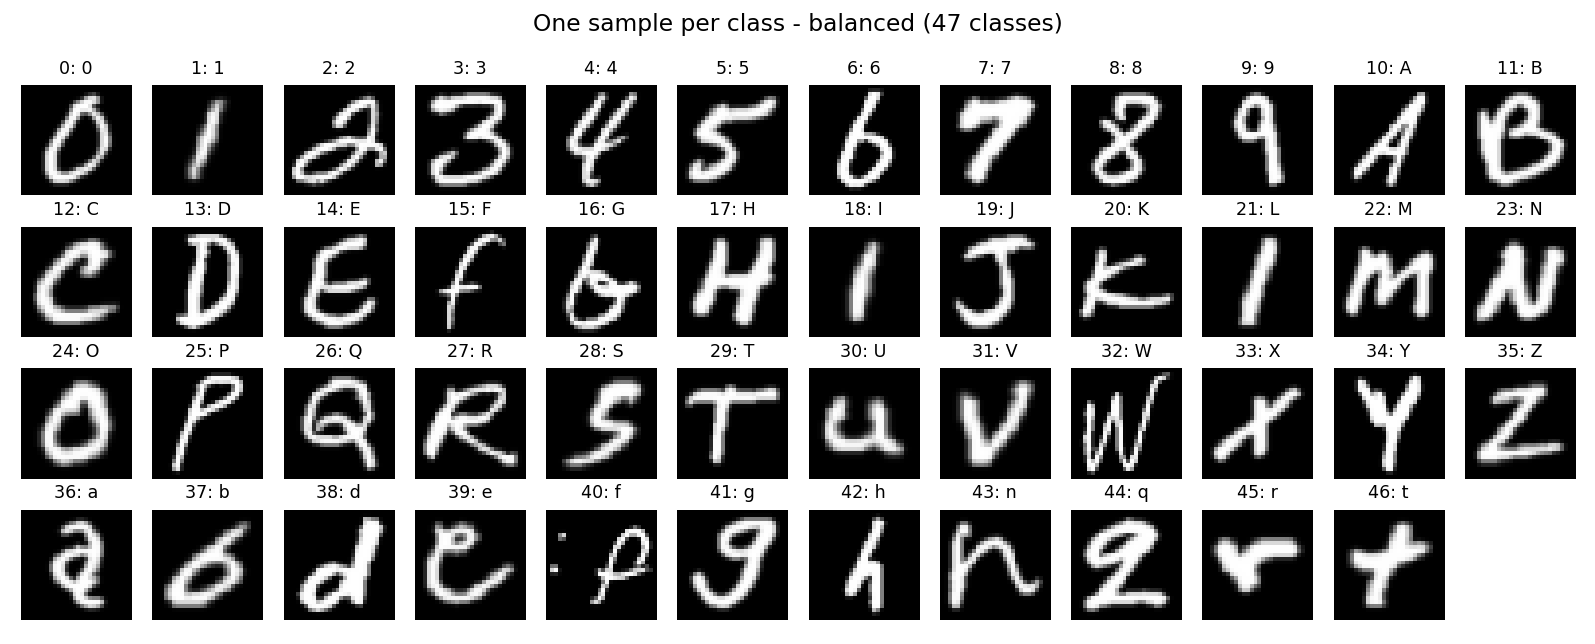

In [6]:
show('eda_balanced_one_per_class.png')

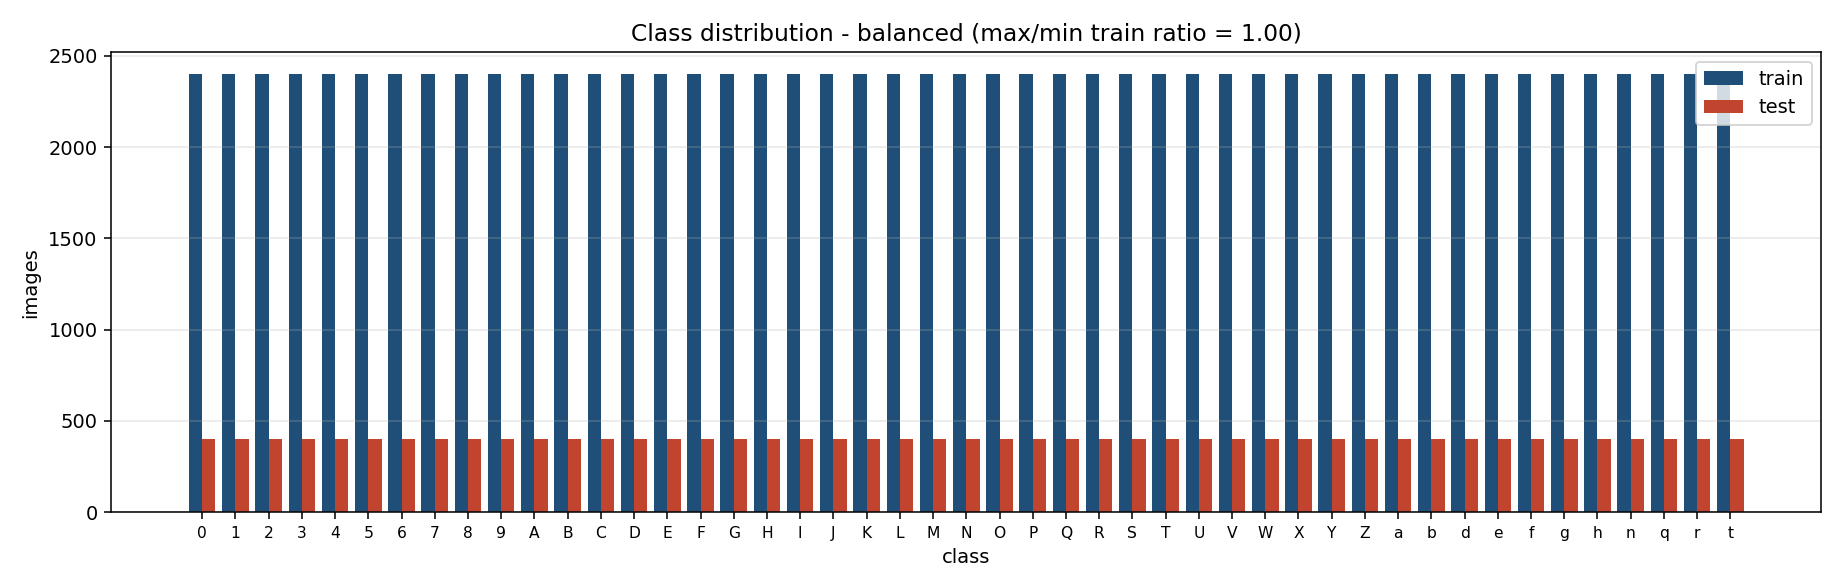

In [7]:
show('eda_balanced_class_distribution.png')

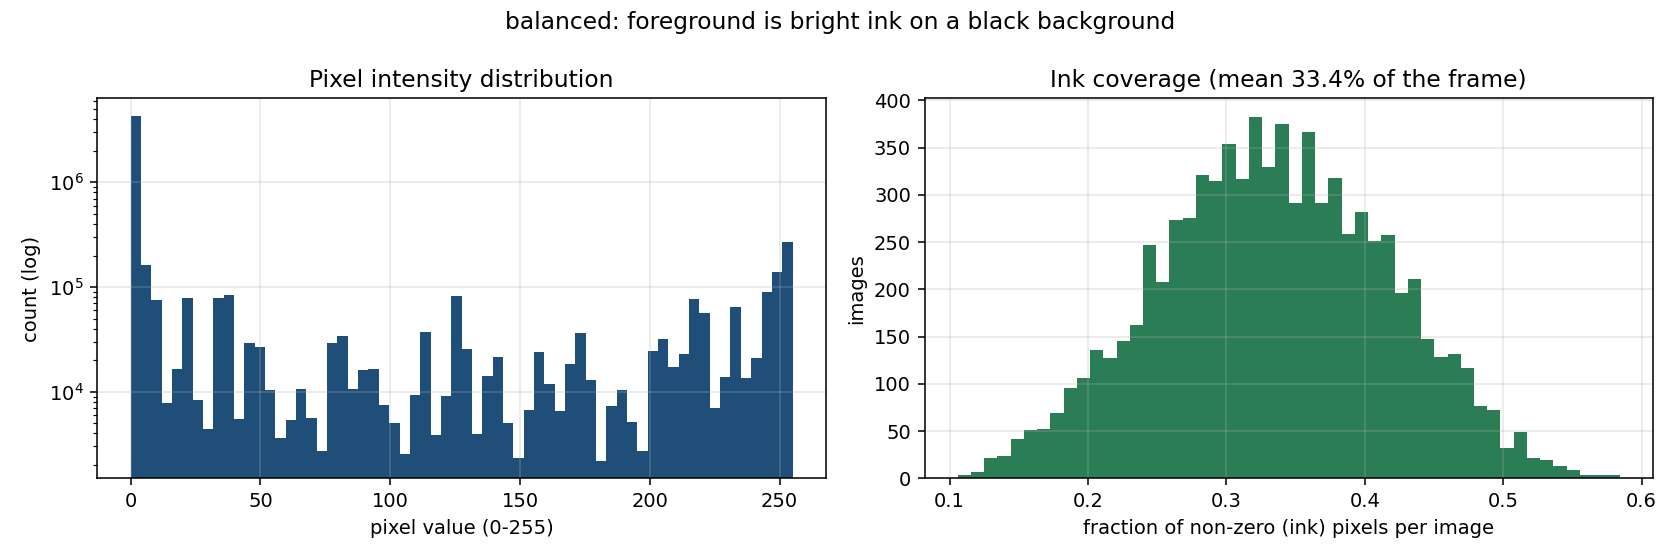

In [8]:
show('eda_balanced_pixel_intensity.png')

The pixel histogram is strongly bimodal - mostly pure-black background with a
bright ink mode - and only a small fraction of each frame is ink. The images are
already background-normalised, so the dataset pipeline needs no background
handling. A *user photo* is a different story - see section 5.

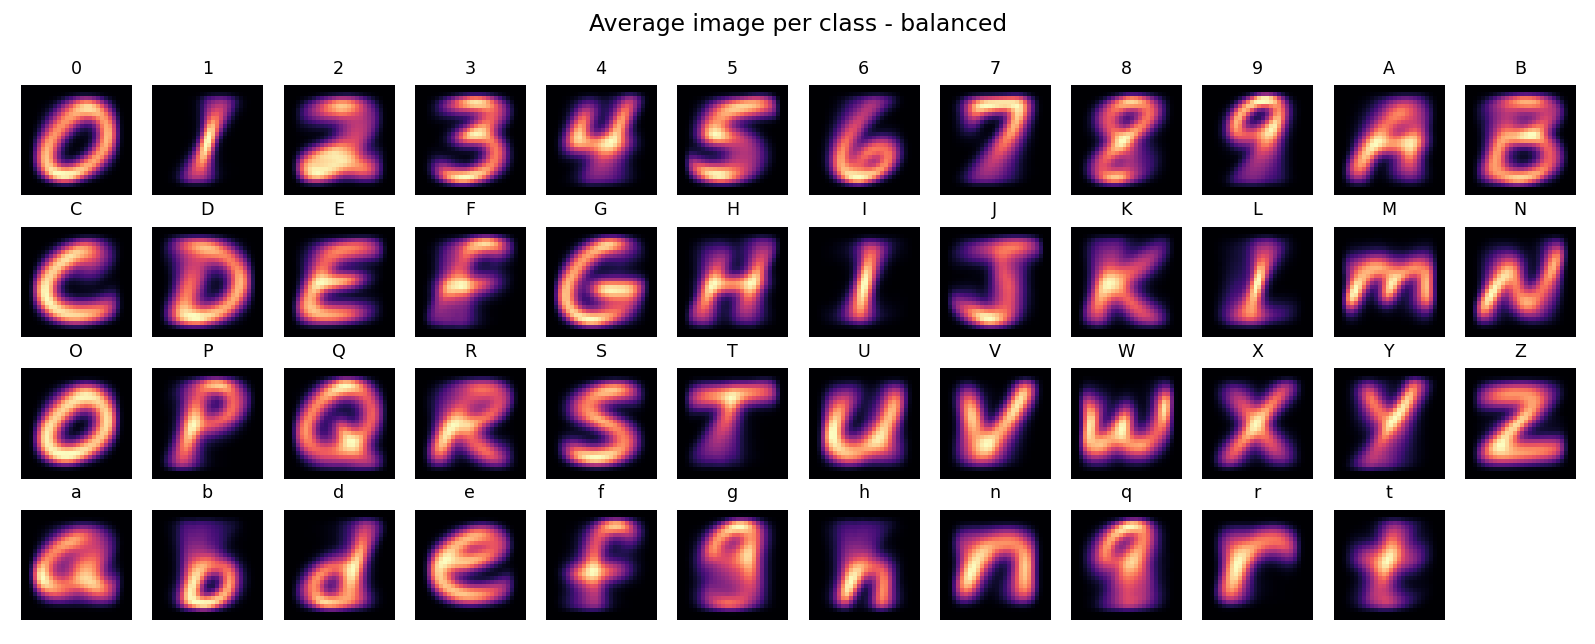

In [9]:
show('eda_balanced_average_per_class.png')

Blurry class averages indicate high within-class variability (many writing
styles); sharp ones indicate consistent shapes. Compare `1` with `g`.

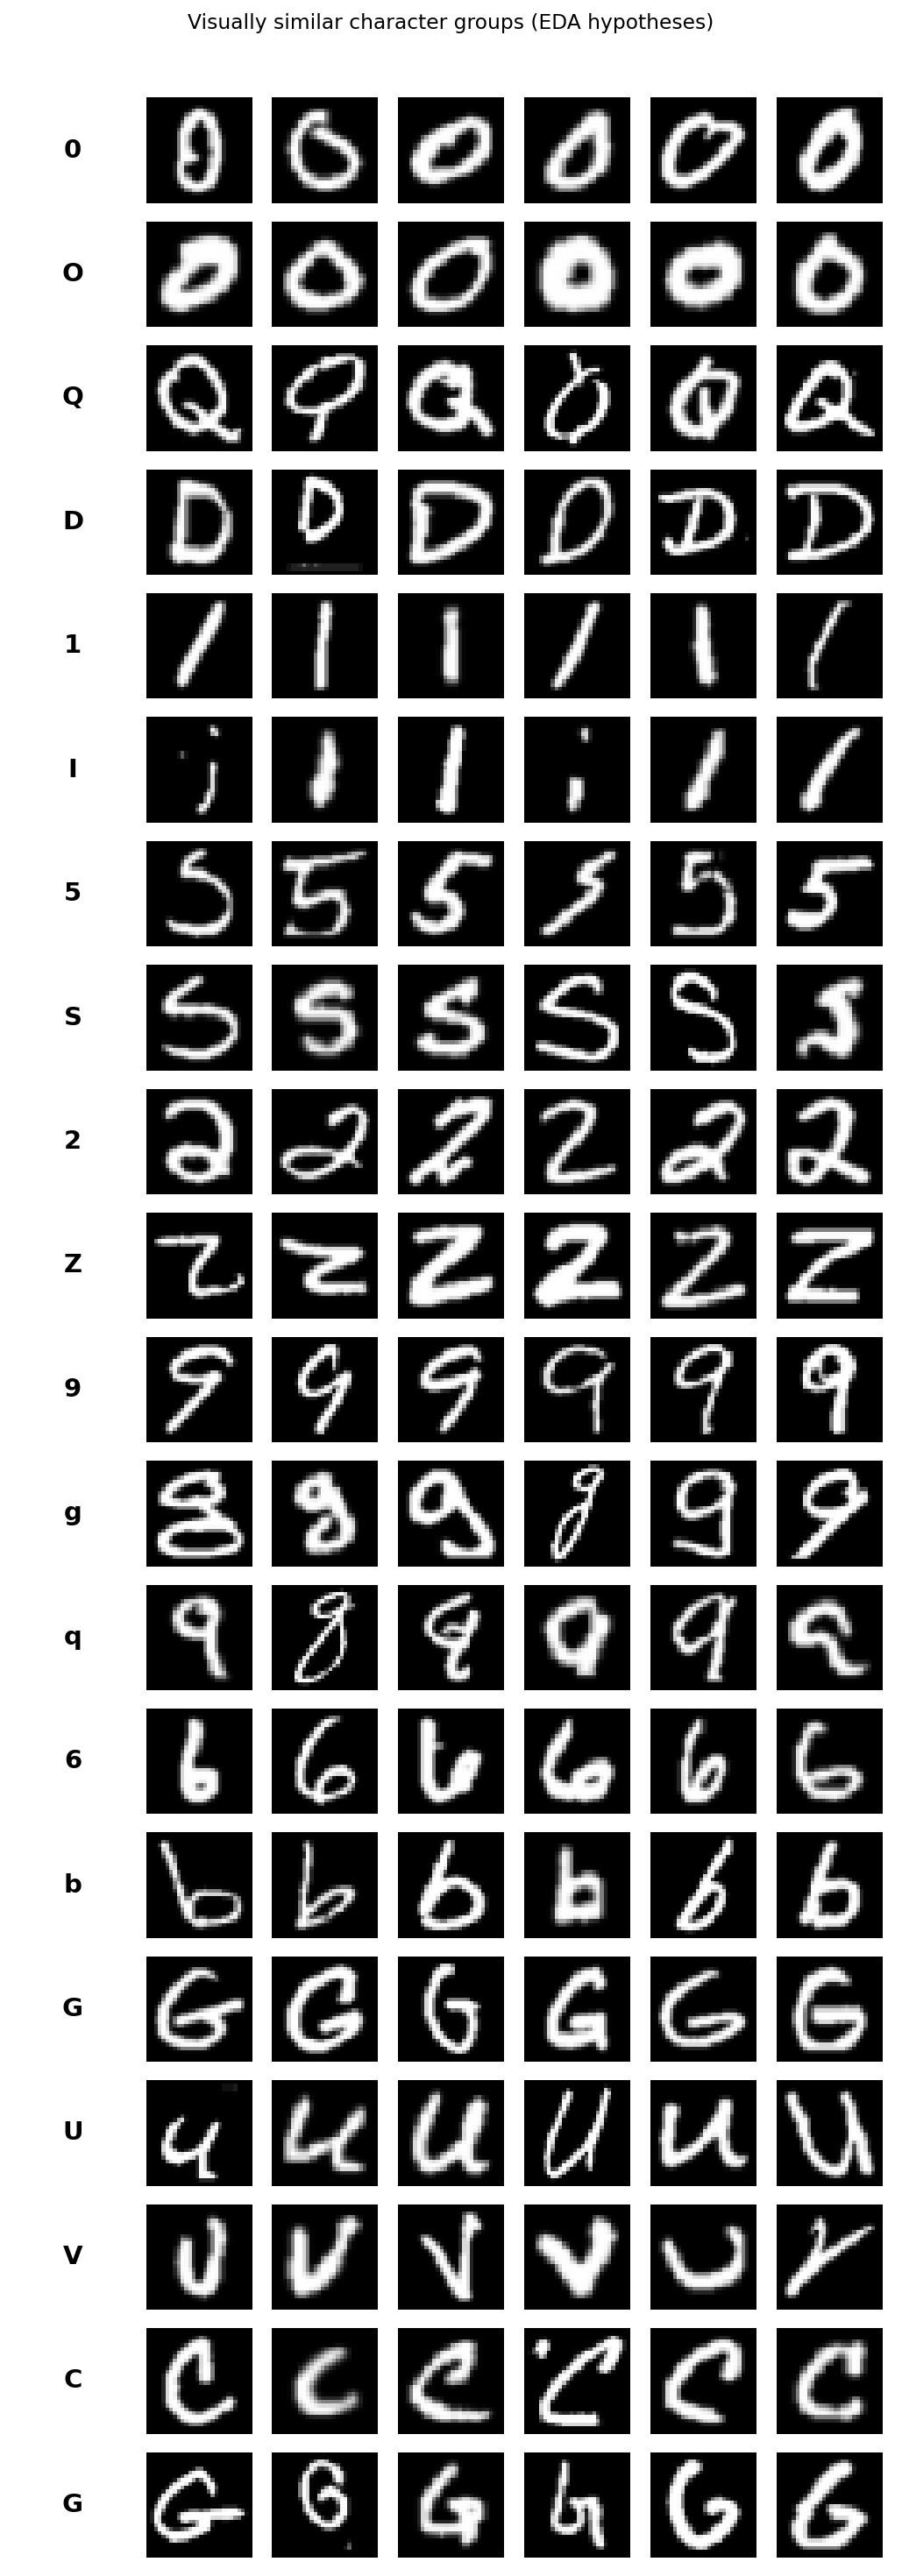

In [10]:
show('eda_balanced_similar_characters.png')

These are *hypotheses* about which characters will be confused. The confusions
reported later come from the real confusion matrix, not from this list.

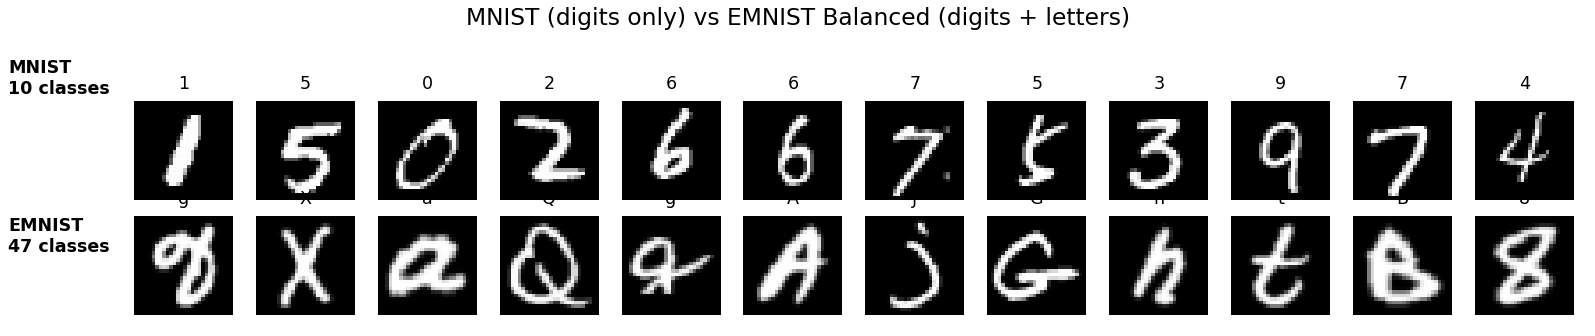

In [11]:
show('eda_mnist_vs_emnist.png')

## 5. Preprocessing

**Dataset images** are already 28x28, deslanted, size-normalised and centred by
NIST, so they need only:

1. the orientation transpose,
2. scaling to `[0, 1]` (keeps gradients well-conditioned),
3. a channel axis -> `(N, 28, 28, 1)`.

They are deliberately **not** upscaled. At 28x28 a stroke is 2-3 px wide; resizing
to 224x224 adds no information, blurs the strokes, and multiplies the compute by
~64x for nothing.

In [12]:
from data_loader import load_emnist
from preprocessing import INPUT_SHAPE, prepare_arrays, preprocessing_config

data = load_emnist('balanced')
x = prepare_arrays(data['x_test'][:5])
print('model input shape :', INPUT_SHAPE)
print('batch shape       :', x.shape, x.dtype)
print('value range       :', float(x.min()), '-', float(x.max()))
print()
print(json.dumps(preprocessing_config(), indent=2))

model input shape : (28, 28, 1)
batch shape       : (5, 28, 28, 1) float32
value range       : 0.0 - 1.0

{
  "image_size": 28,
  "channels": 1,
  "input_shape": [
    28,
    28,
    1
  ],
  "inner_box": 20,
  "scaling": "divide by 255 -> [0, 1]",
  "dataset_orientation_fix": "transpose H and W axes of raw EMNIST IDX images",
  "user_image_pipeline": [
    "read as grayscale (transparency composited onto white)",
    "gaussian blur 3x3",
    "otsu threshold",
    "polarity detection (ink = minority region)",
    "keep largest connected component",
    "crop to ink bounding box",
    "resize longest side to 20 px, aspect preserved",
    "centre by centre of mass in 28x28",
    "scale to [0, 1]"
  ],
  "foreground_convention": "white ink (high values) on black background"
}


### Real-world images are a different problem

A photo of a letter on paper is dark ink on light paper, off-centre, surrounded by
whitespace, unevenly lit and JPEG-compressed. Feeding that straight to the model
fails. The user pipeline reconstructs the NIST conditions: grayscale -> blur ->
Otsu threshold -> polarity detection -> largest blob -> crop to ink -> scale
longest side to 20 px -> centre by centre of mass in 28x28.

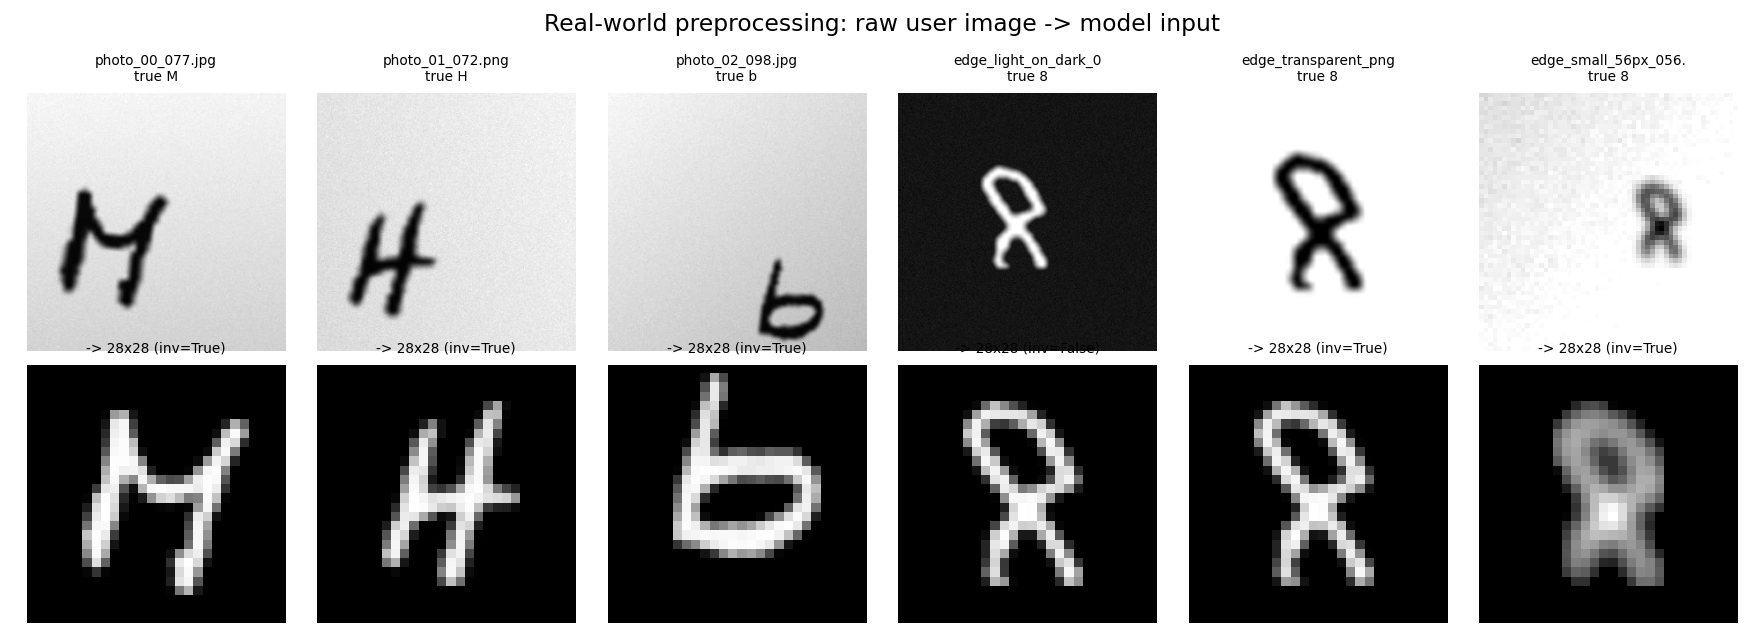

In [13]:
show('phase17_preprocessing_check.png')

## 6. Augmentation

Only transforms that **cannot change the label**: +/-10 degree rotation, +/-10%
translation, +/-10% zoom.

Explicitly excluded, and why:

| Transform | Why it is banned |
|---|---|
| horizontal flip | `b`<->`d`, `p`<->`q` |
| vertical flip | `M`<->`W`, `b`<->`p` |
| rotation >= 45 degrees | `6`<->`9`, `N`<->`Z` |
| heavy shear | destroys thin-stroke letters |

Augmentation is applied **only to the training split**, inside the `tf.data`
pipeline. Validation and test data are never augmented.

{
  "rotation_degrees": 10.0,
  "translation_fraction": 0.1,
  "zoom_fraction": 0.1,
  "fill_mode": "constant (0 = background)",
  "excluded": [
    "horizontal flip (b<->d, p<->q)",
    "vertical flip (M<->W, b<->p)",
    "rotations >= 45 degrees (6<->9, N<->Z)",
    "shear beyond natural slant"
  ],
  "applied_to": "training split only"
}


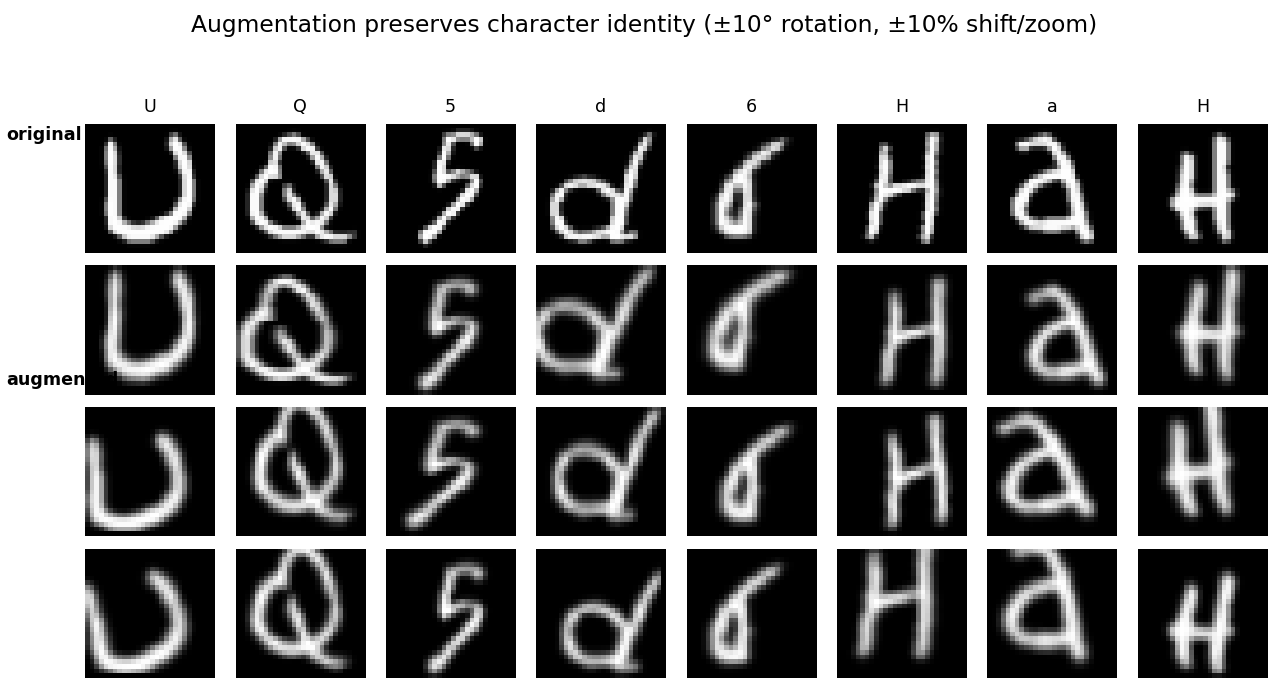

In [14]:
from augmentation import augmentation_config
print(json.dumps(augmentation_config(), indent=2))
show('eda_balanced_augmentation.png')

## 7. Splitting and data leakage

- The **official EMNIST test split (18,800 images) is never touched** during
  training, early stopping or model selection.
- Validation is a **stratified 10%** carved out of the training split with a fixed
  seed, giving exactly 240 validation images per class.
- `evaluate.py` is the only module that reads the test set, and it runs once, after
  the final model has been chosen on validation.

In [15]:
from data_loader import stratified_split

x_tr, y_tr, x_val, y_val = stratified_split(data['x_train'], data['y_train'], 0.1)
counts = np.bincount(y_val)
print(f'train {len(x_tr):,} | val {len(x_val):,} | test (untouched) {len(data["x_test"]):,}')
print(f'validation per class: min {counts.min()}, max {counts.max()} -> perfectly stratified')

train 101,520 | val 11,280 | test (untouched) 18,800
validation per class: min 240, max 240 -> perfectly stratified


## 8. Baselines - how far does classical ML get?

Logistic regression, KNN and a random forest on raw flattened pixels. They are
deliberately **not tuned**: the point is a reference line, not a competition. All
three are fitted on the same 30,000-image stratified subsample (a CPU-budget
decision) and evaluated on the full official test set.

In [16]:
baselines = load_json(METRICS_DIR / 'baselines_emnist_balanced.json')
print(f"{'model':22s} {'test acc':>9s} {'macro F1':>9s} {'fit (s)':>8s}")
for name, r in baselines.items():
    print(f"{name:22s} {r['test']['accuracy']:>9.4f} "
          f"{r['test']['f1_macro']:>9.4f} {r['fit_seconds']:>8.1f}")

model                   test acc  macro F1  fit (s)
logistic_regression       0.6485    0.6466     45.4
knn_k3                    0.7290    0.7296      0.0
random_forest             0.7739    0.7713     38.0


## 9-11. CNN architecture, experiments and training strategy

The architecture is a VGG-style stack built by one configurable function
(`models.build_cnn`), so each experiment changes exactly one thing:

```
Input 28x28x1
  [Conv3x3 -> BN -> ReLU] x2 -> MaxPool2x2 -> Dropout
  [Conv3x3 -> BN -> ReLU] x2 -> MaxPool2x2 -> Dropout
  (deep variant adds a third block)
Flatten -> Dense -> BN -> ReLU -> Dropout -> Dense(47) -> Softmax
```

Training: Adam, batch size 128, sparse categorical cross-entropy, early stopping on
validation loss (patience 5, best weights restored), best-model checkpointing, and
- for the final experiment - `ReduceLROnPlateau`.

### The experiment ladder

In [17]:
table = load_json(METRICS_DIR / 'experiment_table_emnist_balanced.json')
print(f"{'experiment':26s} {'params':>9s} {'ep':>3s} {'val acc':>8s} "
      f"{'val loss':>9s} {'gap':>8s} {'min':>6s}")
for r in table:
    print(f"{r['experiment']:26s} {r['params']:>9,} {r['epochs_run']:>3d} "
          f"{r['val_accuracy']:>8.4f} {r['val_loss']:>9.4f} "
          f"{r['train_val_gap']:>+8.4f} {r['minutes']:>6.1f}")
print()
for r in table:
    print(f"  {r['experiment']}: {r['change']}")

experiment                    params  ep  val acc  val loss      gap    min
exp2_cnn_simple              472,591   8   0.8805    0.3294  +0.0039   11.6
exp3_cnn_bn                  473,551  10   0.8924    0.3082  +0.0171   23.2
exp4_cnn_bn_drop             473,551  12   0.8980    0.2767  -0.0200   24.6
exp5_cnn_bn_drop_aug         473,551  14   0.8877    0.3117  -0.0421   26.9
exp6_cnn_deep_aug_lr         595,791  25   0.9072    0.3298  -0.0098   60.8

  exp2_cnn_simple: How far does a plain CNN (no BN, no dropout) get?
  exp3_cnn_bn: Does batch normalisation help optimisation/accuracy?
  exp4_cnn_bn_drop: Does dropout reduce the train/validation gap?
  exp5_cnn_bn_drop_aug: Does label-preserving augmentation improve generalisation?
  exp6_cnn_deep_aug_lr: Does a deeper model with LR scheduling beat exp5?


`gap` is train accuracy minus validation accuracy at the best epoch - the direct
measure of overfitting. Watch how it moves as dropout and augmentation are added.

## 12. Final evaluation on the untouched test set

In [18]:
final = load_json(METRICS_DIR / 'evaluation_final.json')
summary_model = load_json(METRICS_DIR / 'final_model_summary.json')
m = final['metrics']

print('selected model :', summary_model['selected_experiment'])
print('test images    :', final['n_test'], 'across', final['n_classes'], 'classes')
print()
for key in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
            'precision_weighted', 'recall_weighted', 'f1_weighted']:
    print(f'  {key:20s} {m[key]:.4f}')
print()
print(f"errors: {final['n_errors']} / {final['n_test']} "
      f"(error rate {final['error_rate']:.4f})")

selected model : exp6_cnn_deep_aug_lr
test images    : 18800 across 47 classes

  accuracy             0.9001
  precision_macro      0.9036
  recall_macro         0.9001
  f1_macro             0.8990
  precision_weighted   0.9036
  recall_weighted      0.9001
  f1_weighted          0.8990

errors: 1879 / 18800 (error rate 0.0999)


Because EMNIST Balanced has equal support in every class, **macro F1 and weighted
F1 are nearly identical here**. Macro F1 is still the metric to quote: it weights
every character equally, so a model that is excellent on digits and poor on `q`
cannot hide behind an average.

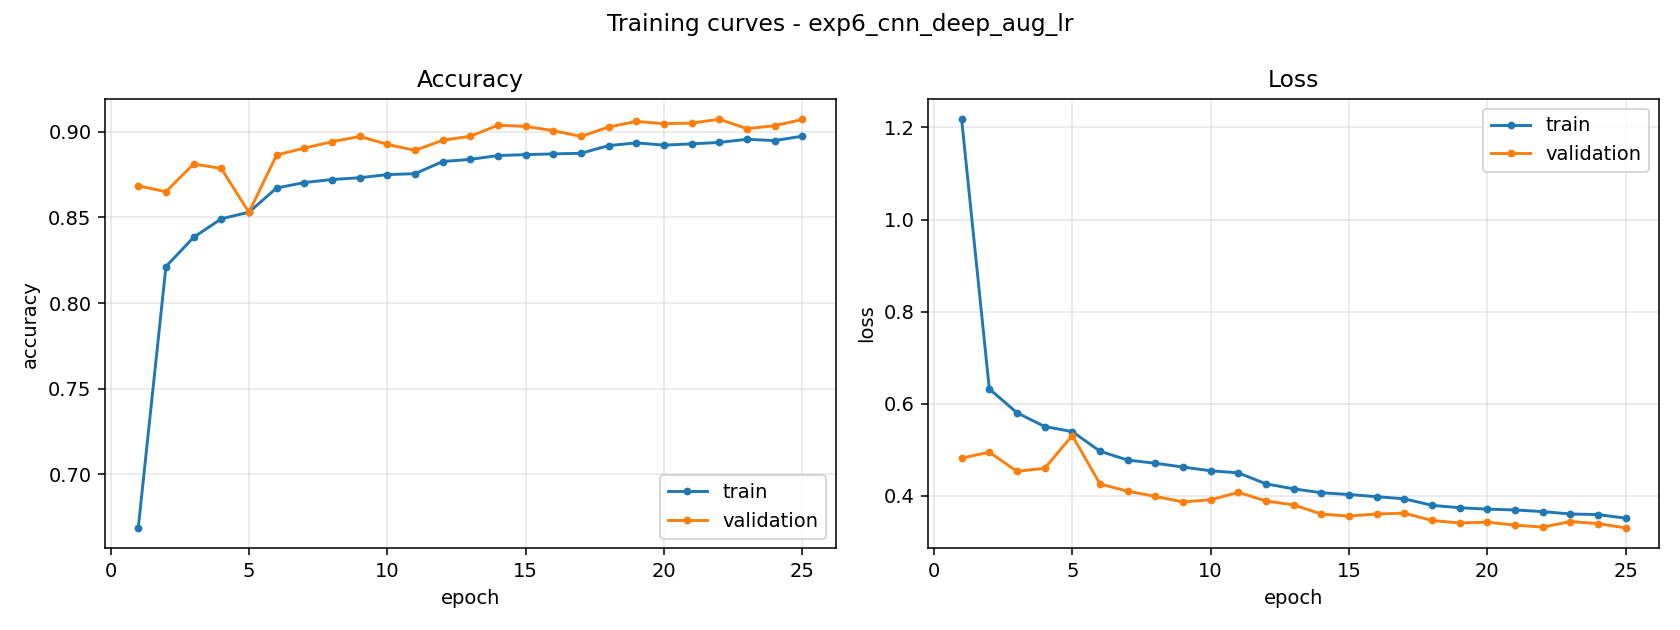

In [19]:
show('final_training_curves.png')

## 13. Confusion matrix analysis

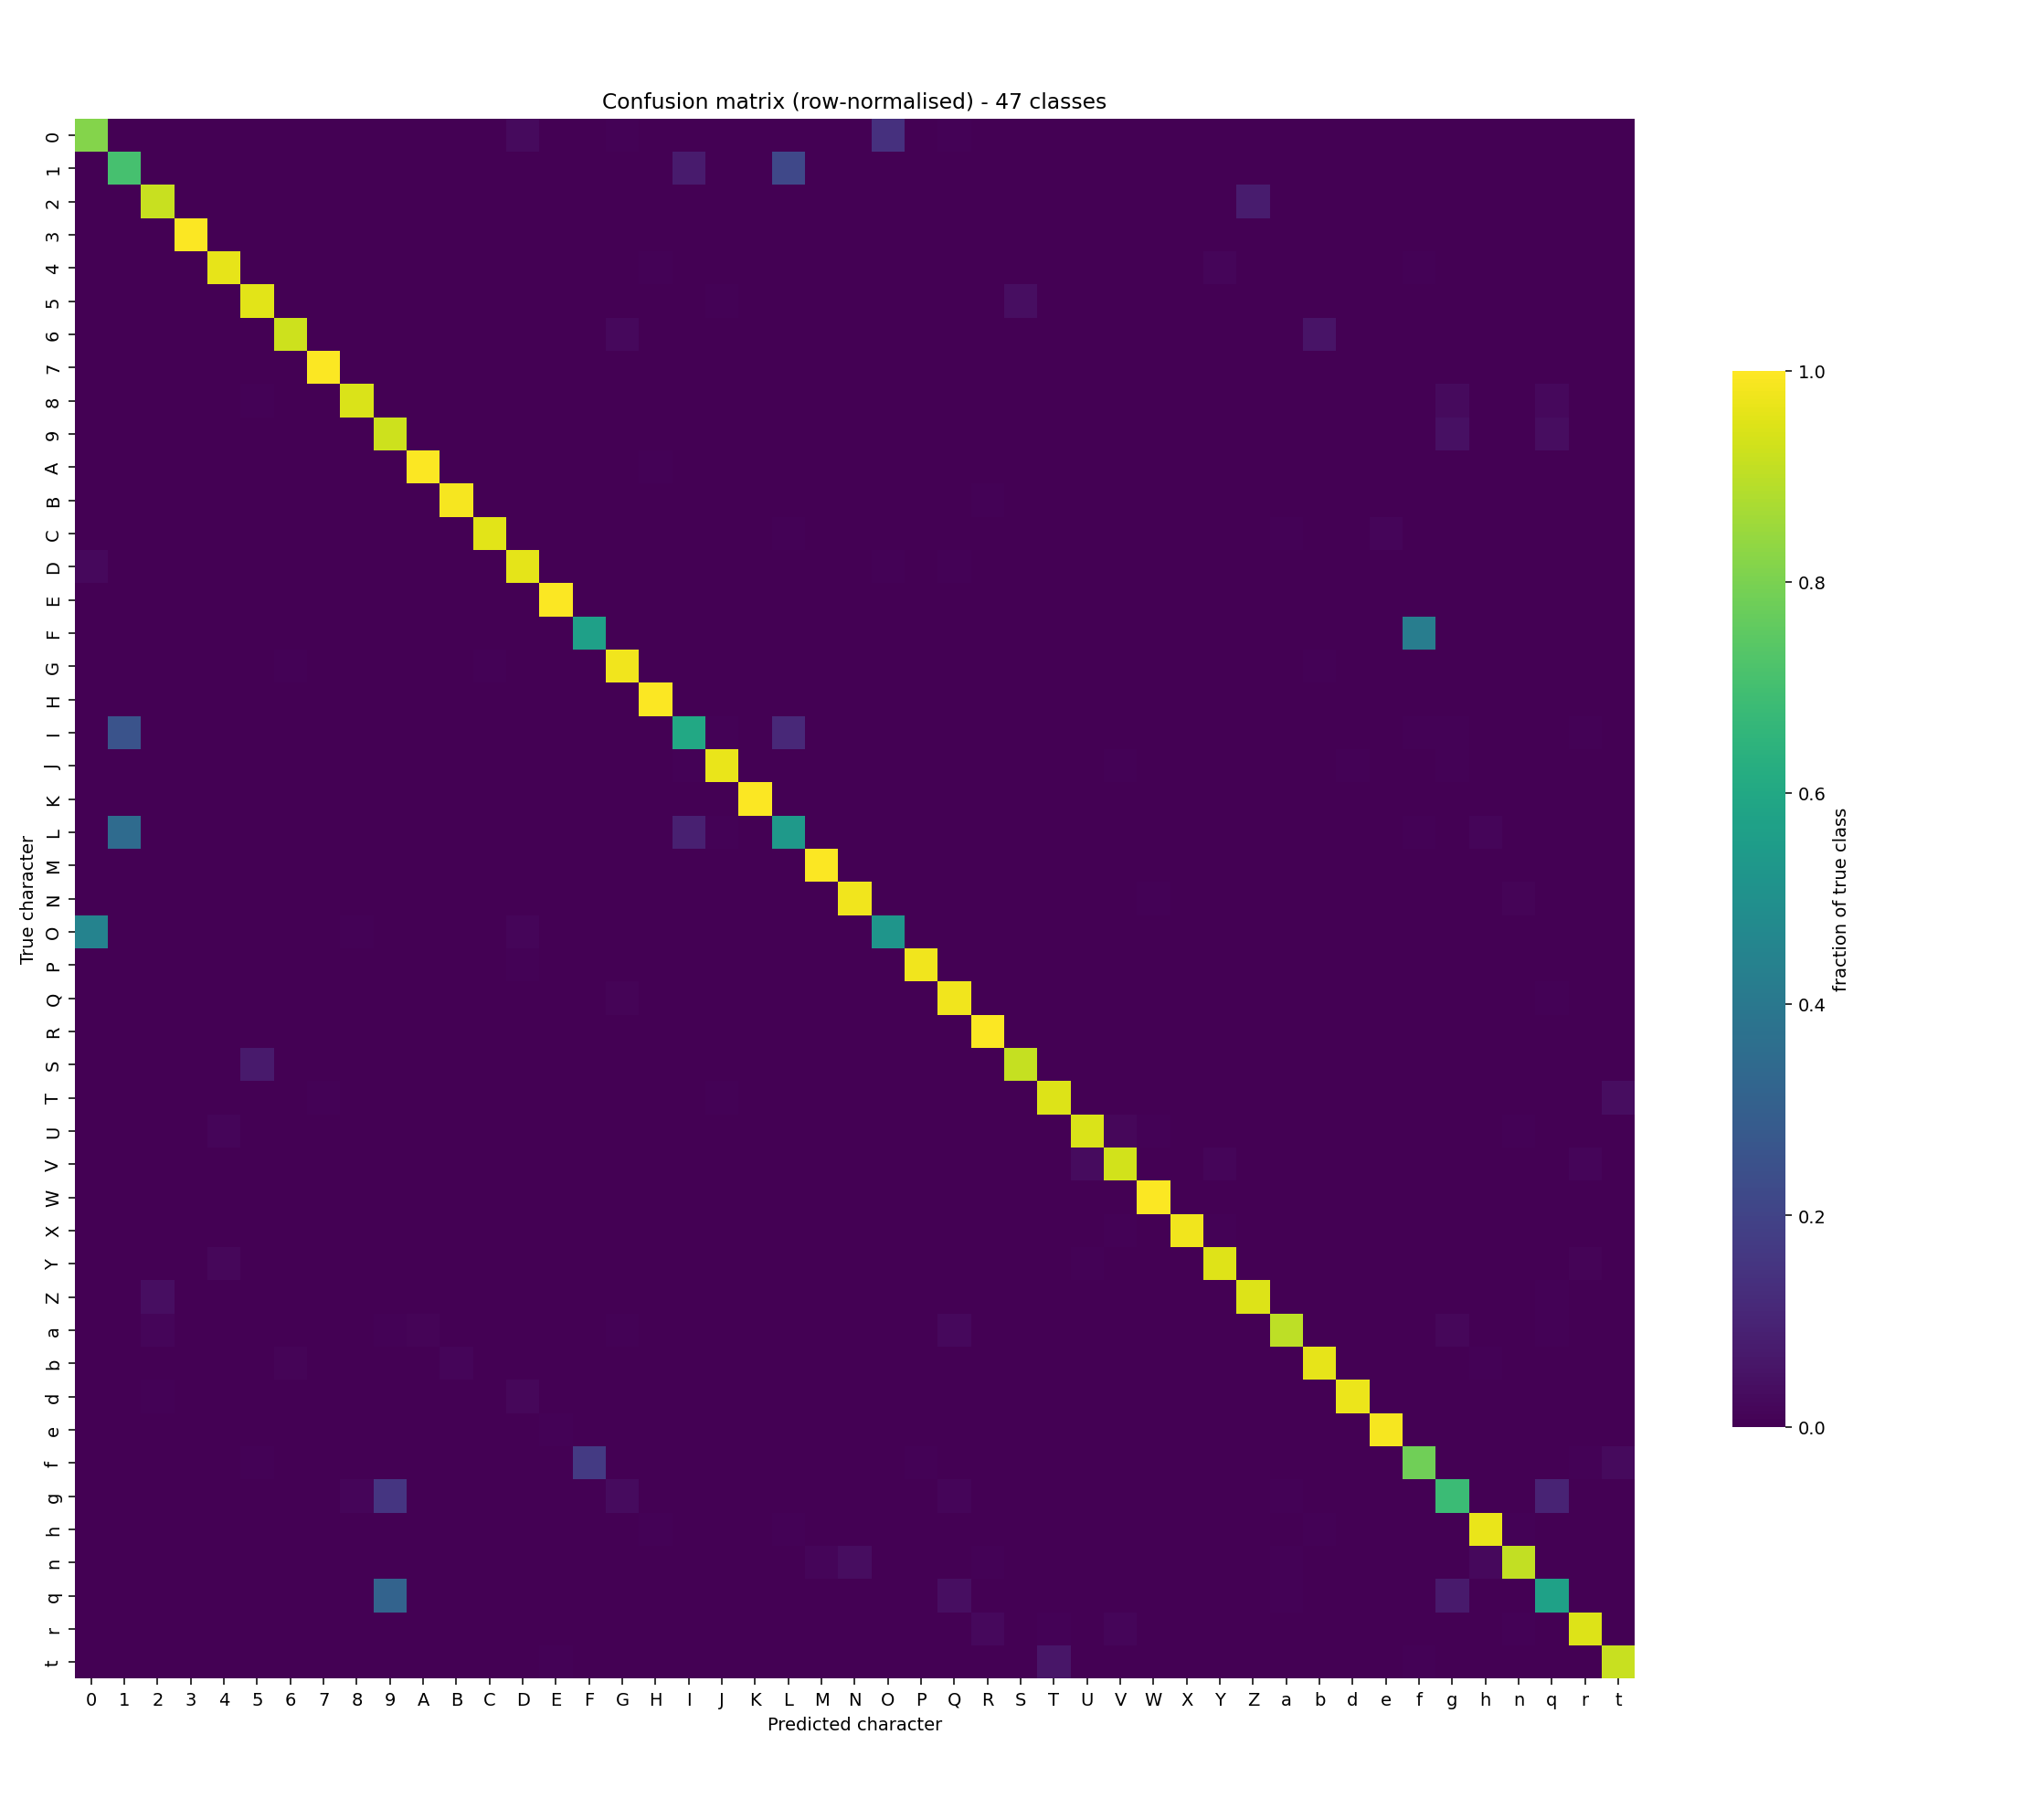

In [20]:
show('final_confusion_matrix_norm.png')

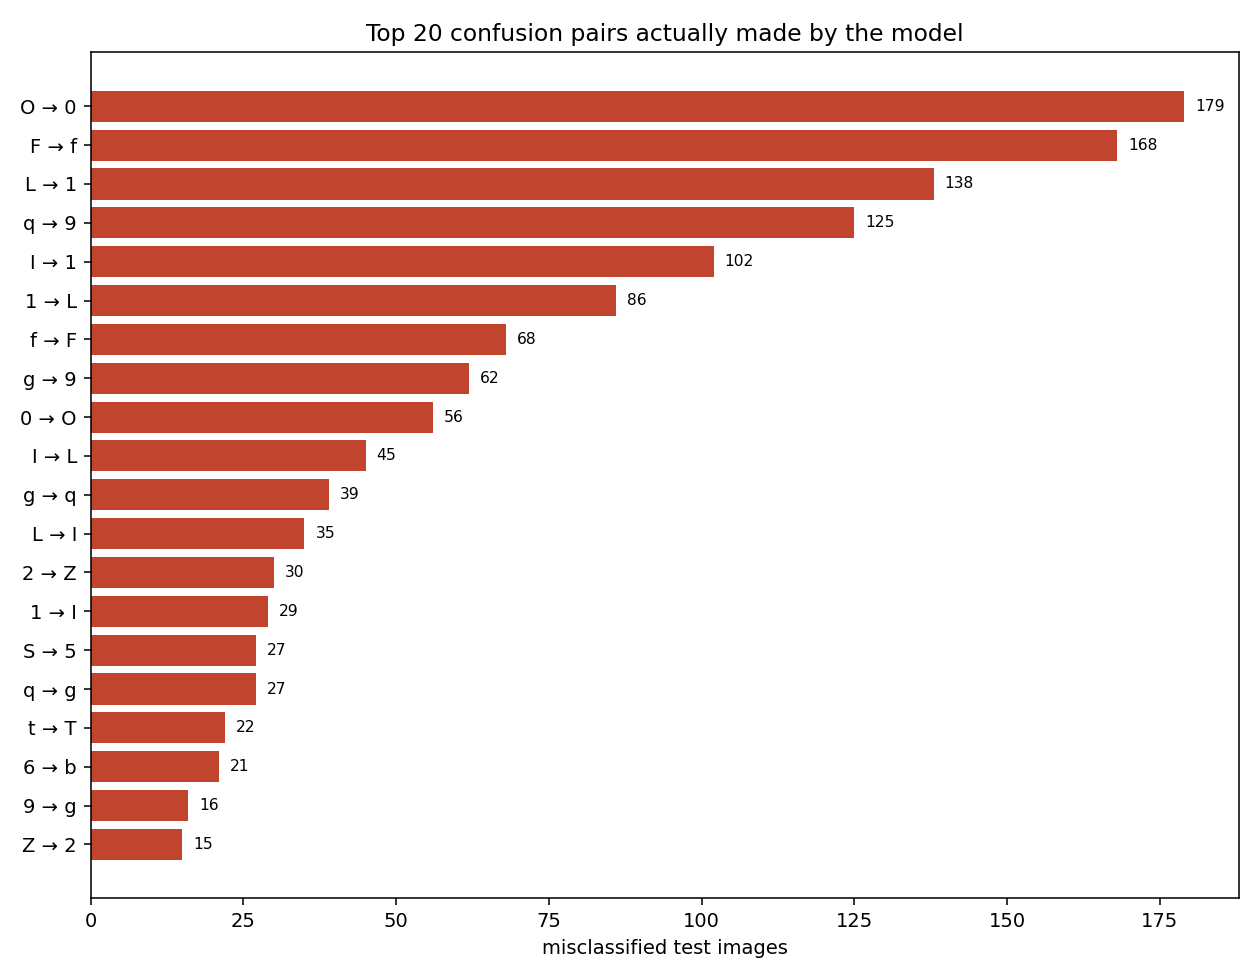

In [21]:
show('final_top_confusions.png', 820)

In [22]:
print(f"{'true':>5s} -> {'pred':<5s} {'count':>6s} {'% of true class':>16s}")
for p in final['top_confusions'][:15]:
    print(f"{p['true']:>5s} -> {p['predicted']:<5s} {p['count']:>6d} "
          f"{p['rate_of_true_class']*100:>15.1f}%")

 true -> pred   count  % of true class
    O -> 0        179            44.8%
    F -> f        168            42.0%
    L -> 1        138            34.5%
    q -> 9        125            31.2%
    I -> 1        102            25.5%
    1 -> L         86            21.5%
    f -> F         68            17.0%
    g -> 9         62            15.5%
    0 -> O         56            14.0%
    I -> L         45            11.2%
    g -> q         39             9.8%
    L -> I         35             8.8%
    2 -> Z         30             7.5%
    1 -> I         29             7.2%
    S -> 5         27             6.8%


### Hardest classes, by per-class F1

In [23]:
print(f"{'char':>5s} {'F1':>7s} {'precision':>10s} {'recall':>8s} {'support':>8s}")
for r in final['hardest_classes']:
    print(f"{r['character']:>5s} {r['f1']:>7.3f} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['support']:>8d}")

 char      F1  precision   recall  support
    L   0.571      0.609    0.537      400
    1   0.612      0.540    0.705      400
    O   0.626      0.780    0.522      400
    F   0.648      0.761    0.565      400
    q   0.650      0.751    0.573      400
    I   0.678      0.779    0.600      400
    f   0.702      0.636    0.785      400
    0   0.710      0.631    0.812      400
    g   0.735      0.800    0.680      400
    9   0.767      0.657    0.922      400


## 14. Error analysis

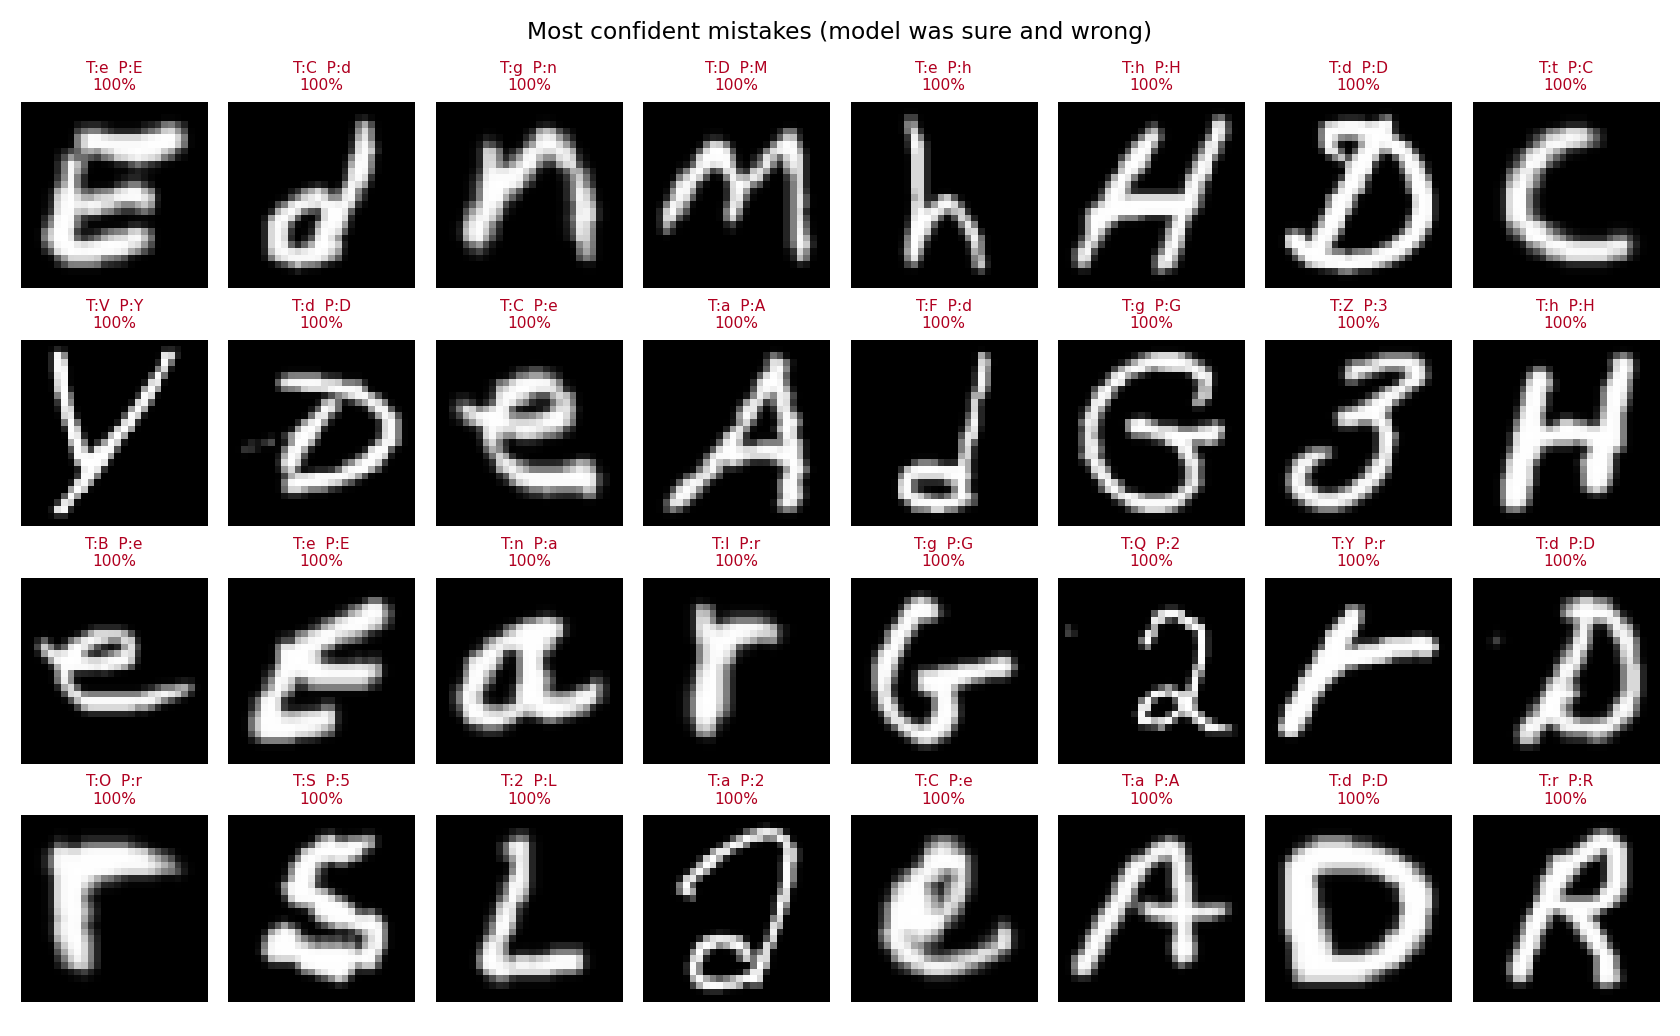

In [24]:
show('final_errors_most_confident.png')

These are the mistakes the model was **most confident about** - the systematic
failures, where the input genuinely looks like the wrong class.

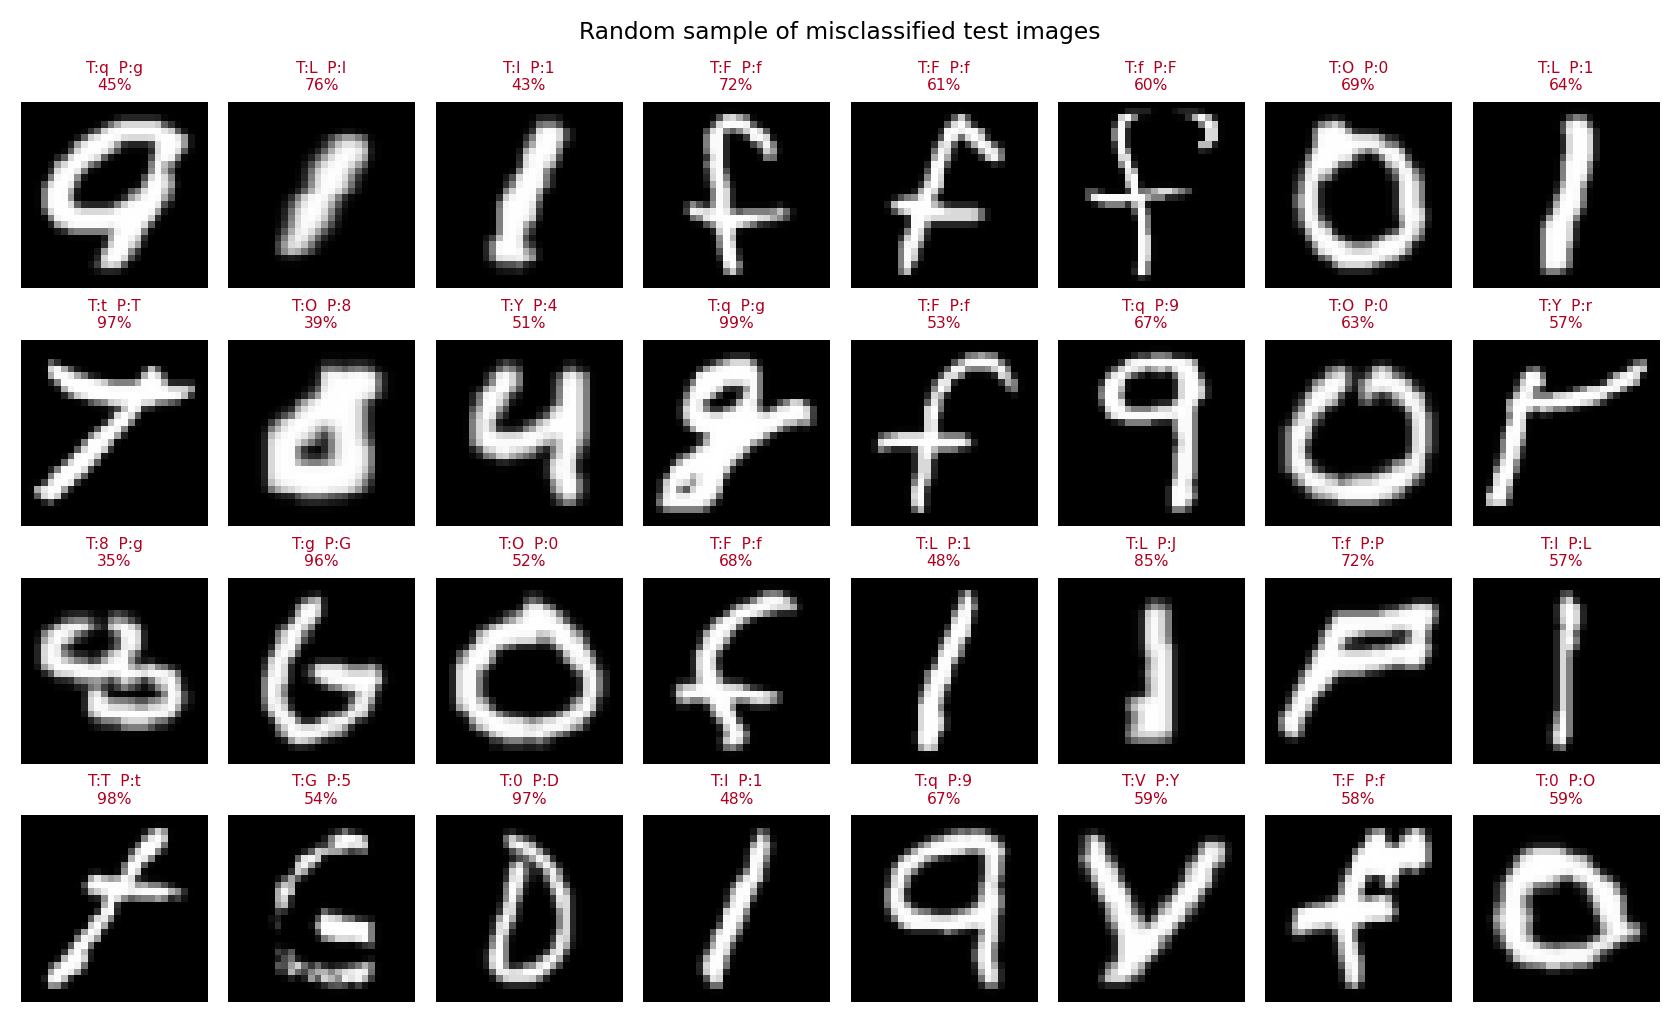

In [25]:
show('final_errors_random.png')

A random sample of errors shows the typical failure mode instead: ambiguous,
rushed or unusually-formed handwriting.

## 15. Confidence analysis

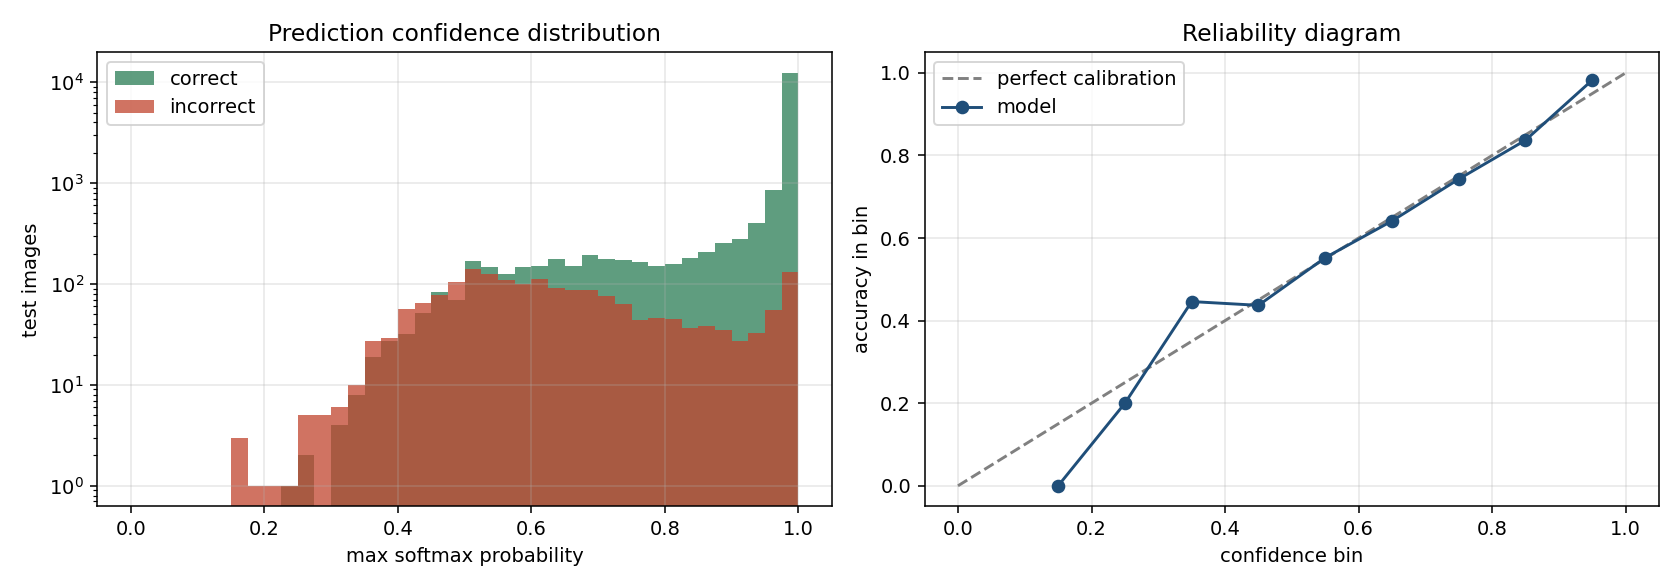

In [26]:
show('final_confidence_analysis.png')

In [27]:
c = final['confidence']
print(f"mean confidence when correct    : {c['mean_confidence_correct']:.4f}")
print(f"mean confidence when incorrect  : {c['mean_confidence_incorrect']:.4f}")
print(f"predictions below 50% confidence: {c['fraction_below_50pct_confidence']*100:.2f}%")
print(f"accuracy when confidence >= 99% : {c['accuracy_on_high_confidence_ge_99pct']:.4f} "
      f"(covers {c['coverage_high_confidence_ge_99pct']*100:.1f}% of the test set)")

mean confidence when correct    : 0.9366
mean confidence when incorrect  : 0.6472
predictions below 50% confidence: 3.66%
accuracy when confidence >= 99% : 0.9926 (covers 58.4% of the test set)


A useful property for a real system: the model is markedly less confident when it
is wrong, so a confidence threshold can route uncertain characters to a human.

## 16-18. Inference on new images, with Top-K

In [28]:
from inference import CharacterRecognizer

recognizer = CharacterRecognizer()
samples = load_json(PREDICTIONS_DIR / 'sample_predictions.json')

print('by image family:')
print(f"{'family':12s} {'n':>3s} {'top-1':>7s} {'top-3':>7s} {'top-5':>7s}")
for family, s in samples['by_family'].items():
    print(f"{family:12s} {s['n']:>3d} {s['top1_accuracy']:>7.3f} "
          f"{s['top3_accuracy']:>7.3f} {s['top5_accuracy']:>7.3f}")
print()
print(samples['note'])

by image family:
family         n   top-1   top-3   top-5
edge_case      5   1.000   1.000   1.000
font          12   1.000   1.000   1.000
photo         24   1.000   1.000   1.000

These are simulated camera/scan renderings of unseen EMNIST test glyphs and printed-font glyphs, not photographs of a real person's handwriting. The 'font' family is deliberately out of distribution.


In [29]:
# A single prediction, end to end, from an image file on disk.
row = samples['predictions'][0]
prediction = recognizer.predict_image(row['path'], top_k=5)
print('image      :', Path(row['path']).name)
print('true label :', row['true_label'])
print()
print(prediction.format())

image      : photo_00_077.jpg
true label : M

Predicted Character: M
Confidence: 99.9%

Top predictions:
  1. M  -  99.87%  ##############################
  2. n  -   0.05%  #
  3. H  -   0.04%  #
  4. N  -   0.02%  #
  5. U  -   0.01%  #


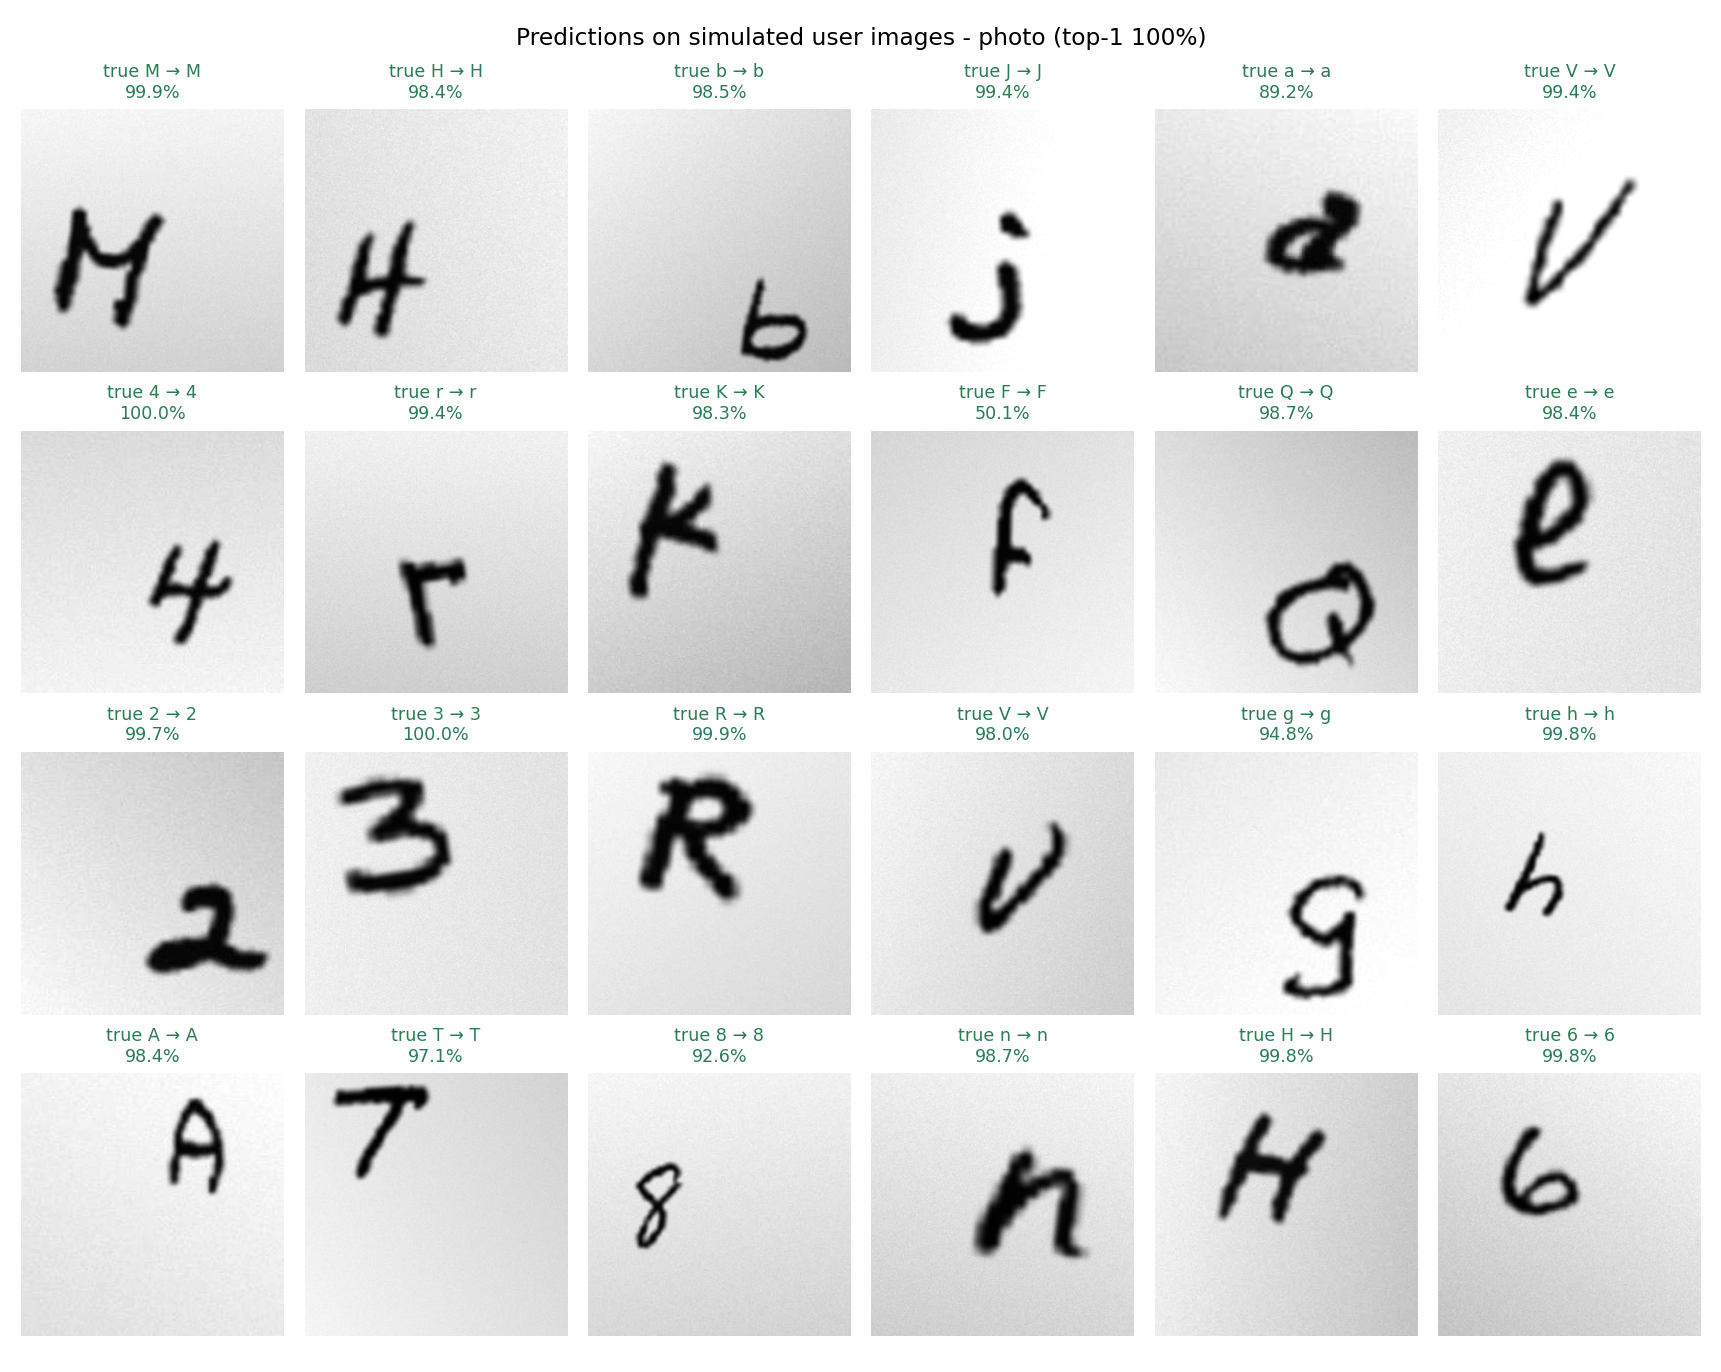

In [30]:
show('samples_photo.png')

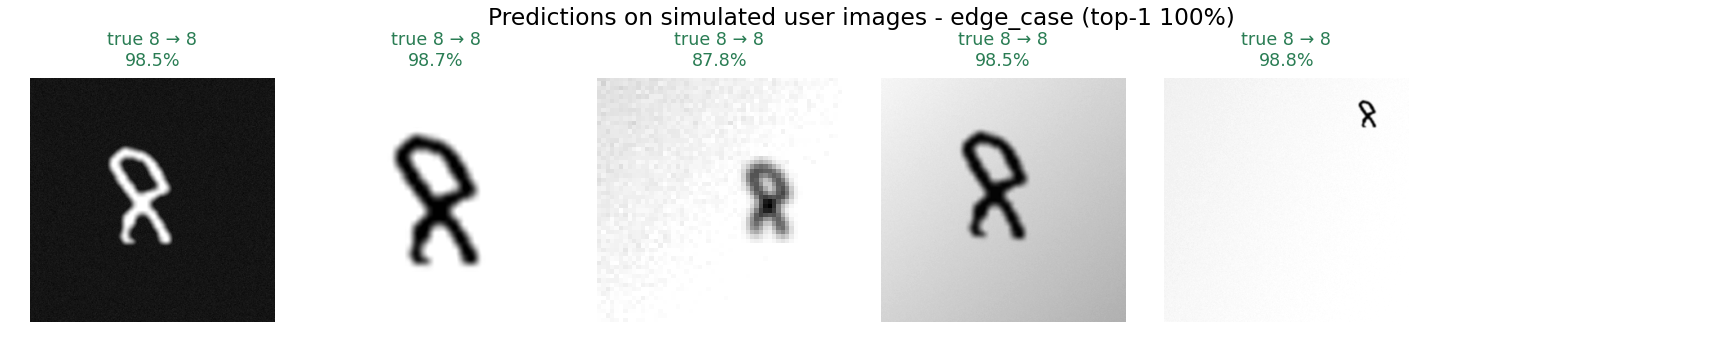

In [31]:
show('samples_edge_case.png', 820)

The `font` family is printed type, not handwriting - genuinely out of
distribution, and included to show where the model's domain ends rather than to
flatter it.

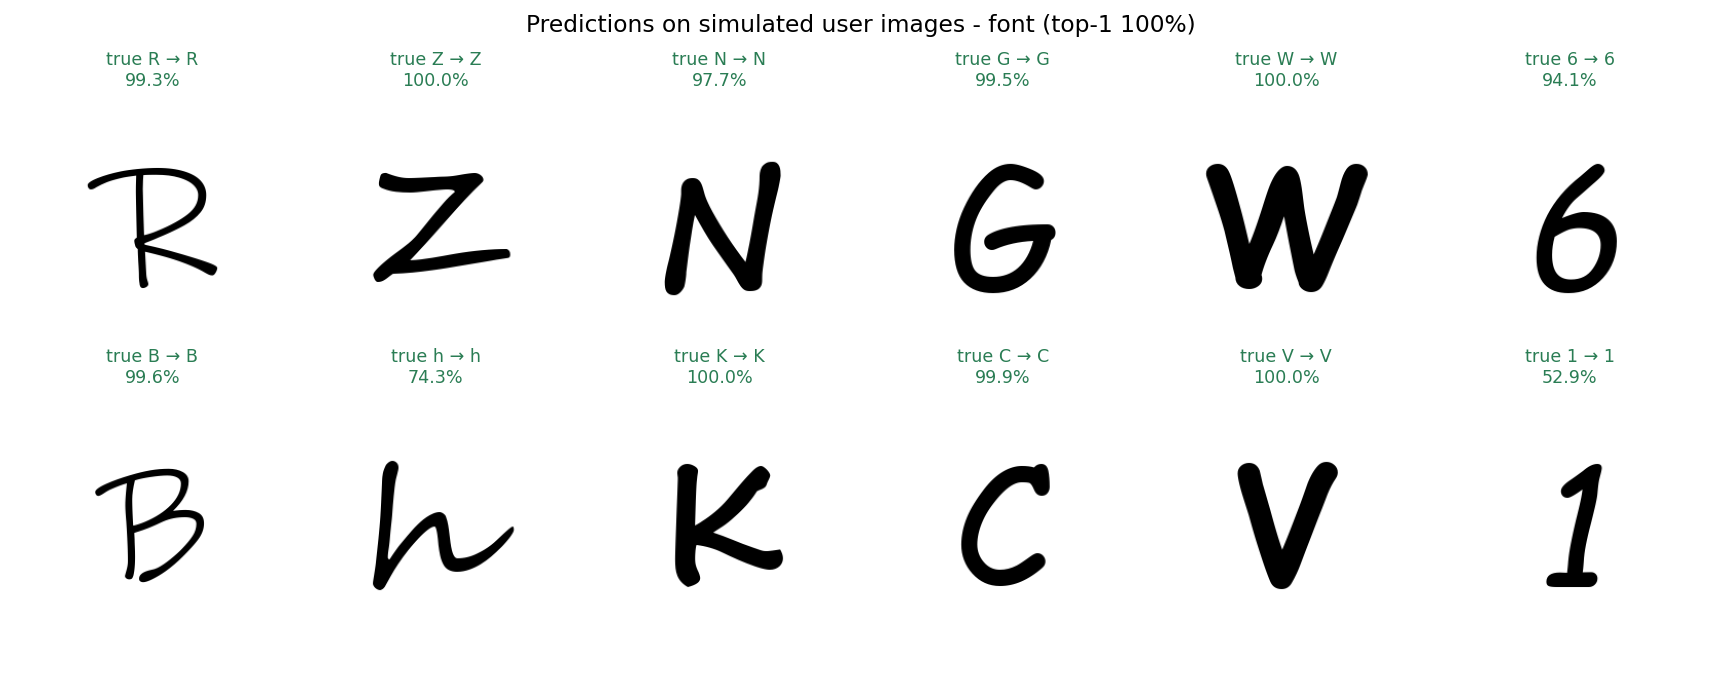

In [32]:
show('samples_font.png')

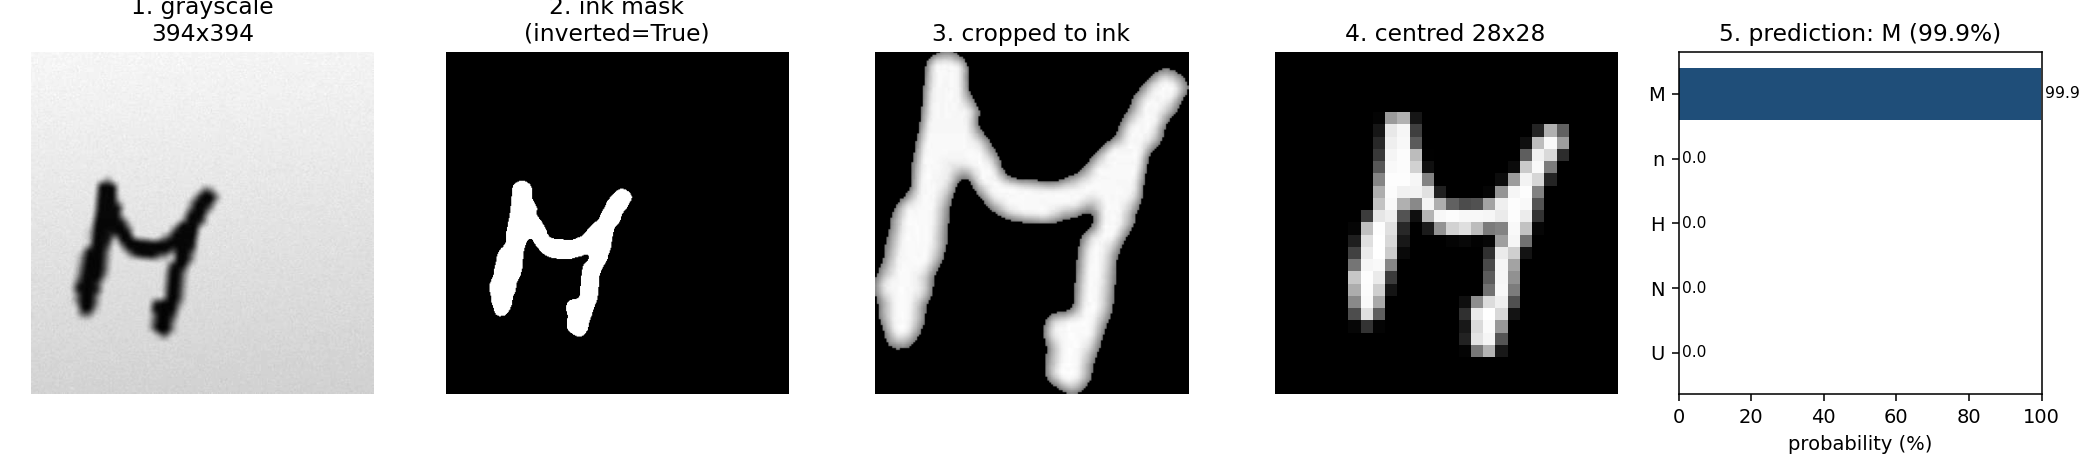

In [33]:
show(f"inference_steps_{Path(samples['predictions'][0]['path']).stem}.png")

## 19. Model export and reload verification

The exported model is reloaded into a fresh object and its probabilities compared
against the source model on a fixed batch. If saving were lossy, this check fails
loudly rather than silently degrading inference.

In [34]:
s = summary_model
print(json.dumps(s['exported'], indent=2))
print()
print('reload verification:', json.dumps(s['reload_verification'], indent=2))
print()
labels = load_json(Path(s['exported']['labels']))
print('labels.json holds', labels['n_classes'], 'classes:', ' '.join(labels['class_names']))

{
  "model": "C:\\Hand Written Character recognition\\models\\final\\handwritten_character_cnn.keras",
  "labels": "C:\\Hand Written Character recognition\\models\\final\\labels.json",
  "config": "C:\\Hand Written Character recognition\\models\\final\\preprocessing_config.json"
}

reload verification: {
  "n_compared": 256,
  "max_abs_probability_difference": 0.0,
  "labels_identical": true
}

labels.json holds 47 classes: 0 1 2 3 4 5 6 7 8 9 A B C D E F G H I J K L M N O P Q R S T U V W X Y Z a b d e f g h n q r t


## 20. Extension to words and sentences - CRNN

This project is a **character** classifier, and the honest way to extend it to
words is *not* to slice an image into letters and classify each one - segmentation
is exactly what breaks on cursive and touching characters.

The correct architecture is a **CRNN trained with CTC loss**:

```
Word image (H x W x 1, variable width)
  -> CNN feature extractor      (keeps width, collapses height)
  -> feature map reshaped into a left-to-right sequence of frames
  -> BiLSTM / BiGRU             (each frame sees left and right context)
  -> Dense(vocab + 1 blank) -> softmax per frame
  -> CTC loss (training) / CTC decode (inference)
```

**Why CTC matters:** the number of output frames (say 64) never matches the number
of characters (say 5), and nobody labels *which* pixel column each letter starts
at. CTC sums probability over every alignment of frames to the target string -
inserting a special *blank* symbol and collapsing repeats - so the model learns
alignment implicitly from `(image, "hello")` pairs alone.

**Why it was not implemented here:** it needs a word-level dataset (IAM Words or
similar, which requires a registered download), and CRNN+CTC training is roughly an
order of magnitude more expensive than this CNN - impractical on the CPU-only
machine this project was built on. Per the brief, a complete and verified character
system beats a half-trained word system, so the CRNN is documented as future work
rather than faked.

## Conclusion

See `report.md` for the full write-up. Summary of what this notebook demonstrated,
all from executed results:

- EMNIST Balanced chosen and justified against five alternatives.
- The orientation trap identified and fixed, verified numerically and visually.
- Classical baselines established, then beaten substantially by the CNN.
- A controlled experiment ladder isolating BN, dropout, augmentation and depth.
- Evaluation on a genuinely untouched test set with macro F1, not just accuracy.
- Confusions and errors reported from the real confusion matrix.
- A saved model that reloads exactly and predicts on new images with Top-K
  confidences.